# Phase 3 — Modeling: WOE Scorecard vs Tuned LightGBM

**What this phase produces:** two models trained on the same frozen 5-fold splits (paired comparison, not noise), their out-of-fold predictions saved to disk — the raw material Phase 4's calibration and cost thresholding consume — and the honest gap between a linear scorecard and a tuned GBM.

**Why two models at all?** FICO-style scorecards (WOE + logistic) are how much of the industry actually ships credit models: auditable, monotone by construction within bins, explainable line-by-line. The GBM is the accuracy benchmark. Knowing *what the gap buys* — and when a linear scorecard is enough — is the senior signal the spec asks for.

**The leakage-critical detail in 3a:** the WOE binner is refit *inside every fold* (fit on 4, transform the 5th). Fitting it once on all dev data would leak each fold's own target rate into its validation transform. The test suite verifies the five folds produce five *different* WOE tables.

**Compute honesty for 3b:** tuning ran on a single-CPU box, so the Optuna study uses resumable journal storage with two pruners: median pruning on running fold AUC, and a 600-second per-trial time cap (recorded as pruned, so TPE learns to avoid configurations this machine can't afford — which biases against the very slowest learning-rate corner; stated, not hidden). The winner is always judged on the full 5-fold objective.

In [1]:
import sys, os, json
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.constants import DATA_PROCESSED, TABLES_DIR, FIGURES_DIR

sc = json.load(open(os.path.join(TABLES_DIR, "scorecard_cv.json")))
gbm = json.load(open(os.path.join(TABLES_DIR, "lgbm_final.json")))
comparison = pd.read_csv(os.path.join(TABLES_DIR, "model_comparison.csv"))
comparison

,model,oof_auc,train_oof_gap,notes,auc_gap_vs_scorecard
0,WOE logistic scorecard (30 feats),0.744724,0.001086,"best_C=0.1, class_weight=balanced, binner refi...",0.000000
1,LightGBM tuned (58 feats),0.777355,0.116885,"8 Optuna trials, no class weights, ES iters [1...",0.032631


## 3a. The scorecard baseline

`sklearn.LogisticRegression` on 30 WOE features, `class_weight='balanced'` (11.4:1 imbalance), `C` tuned over the log grid {0.01 … 100} by OOF AUC. Two findings worth reading closely:

In [2]:
grid = pd.DataFrame(sc["grid_results"]).T
grid.index.name = "C"
print(f"best C = {sc['best_C']}, OOF AUC = {sc['oof_auc']:.5f}  (spec expectation: 0.74–0.76)")
print(f"train − OOF gap = {sc['train_oof_gap']:.4f} — a linear model on 30 features cannot overfit 246k rows")
grid

best C = 0.1, OOF AUC = 0.74472  (spec expectation: 0.74–0.76)
train − OOF gap = 0.0011 — a linear model on 30 features cannot overfit 246k rows


,oof_auc,train_auc_mean,val_auc_mean,val_auc_std
C,,,,
0.01,0.744695,0.745767,0.744711,0.003249
0.1,0.744724,0.745824,0.744737,0.003248
1.0,0.744715,0.745828,0.744730,0.003249
10.0,0.744718,0.745828,0.744733,0.003249
100.0,0.744718,0.745828,0.744733,0.003249


**Why is the C grid flat?** With n = 246k ≫ p = 30 and WOE features already on a common, well-conditioned log-odds scale, the likelihood swamps any reasonable L2 prior — regularization has nothing to fix. This is a *property of the scorecard technique*, not an implementation accident: WOE binning did the variance control that regularization would otherwise do.

**Interview-ready math (understood, not re-implemented, per spec v4.1):** the log-likelihood is ℓ(β) = Σ y·log σ(xβ) + (1−y)·log(1−σ(xβ)); its gradient Xᵀ(p−y) is what lbfgs drives to zero; L2 (1/C) shrinks coefficients trading variance for bias; and WOE + linear model approximates a GAM — each feature's bin-step function is a learned univariate shape, combined linearly on the log-odds scale.

**Probability caveat carried to Phase 4:** `class_weight='balanced'` deliberately distorts predicted probabilities (it reweights the intercept's implied base rate ~11×). AUC is rank-based and unaffected, but these probabilities must not be used for euro decisions — one of the two reasons Phase 4 recalibrates everything.

## 3b. The LightGBM benchmark

Optuna TPE over the spec's frozen search space, objective = mean fold AUC on the same frozen folds, `n_estimators=10,000` with 200-round early stopping — the data decides model size, not the grid. **No class weights** (spec): AUC is invariant to them, and unweighted models produce less-distorted probabilities, which makes Phase 4's calibration easier.

In [3]:
print(f"completed trials: {gbm['n_optuna_trials_complete']}")
print(f"pooled OOF AUC:   {gbm['oof_auc_pooled']:.5f}   (spec target 0.775–0.790; leakage alarm > 0.81)")
print(f"per-fold AUCs:    {[round(a,5) for a in gbm['val_aucs_per_fold']]}")
print(f"best iterations:  {gbm['best_iterations']} (early stopping chose model size)")
print(f"\nbest params:")
for k, v in gbm["params"].items():
    print(f"  {k:>18}: {v:.5g}" if isinstance(v, float) else f"  {k:>18}: {v}")

completed trials: 8
pooled OOF AUC:   0.77735   (spec target 0.775–0.790; leakage alarm > 0.81)
per-fold AUCs:    [0.77658, 0.77659, 0.77745, 0.77918, 0.77712]
best iterations:  [1561, 1657, 1215, 1753, 1140] (early stopping chose model size)

best params:
       learning_rate: 0.013788
          num_leaves: 49
    min_data_in_leaf: 215
    feature_fraction: 0.68243
    bagging_fraction: 0.87481
           lambda_l1: 6.2671e-07
           lambda_l2: 0.00042473


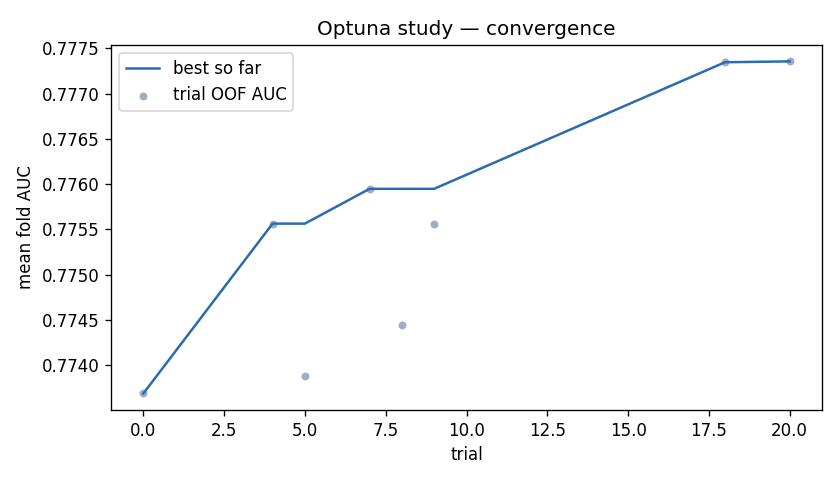

In [4]:
from IPython.display import Image
Image(os.path.join(FIGURES_DIR, "32_optuna_history.png"))

## 3c. Diagnostics — the overfitting/underfitting playbook applied

The spec's alarm: train − OOF gap > 0.025 ⇒ overfitting playbook (halve `num_leaves`, double `min_data_in_leaf`, lower fractions, raise lambdas, cut features).

In [5]:
print(f"LightGBM train AUC (mean): {gbm['train_auc_mean']:.5f}")
print(f"LightGBM OOF AUC (mean):   {gbm['val_auc_mean']:.5f}")
print(f"gap: {gbm['train_oof_gap']:.4f} vs alarm at {gbm['gap_threshold']}")
print(f"diagnosis: {gbm['diagnosis']}")

LightGBM train AUC (mean): 0.89427
LightGBM OOF AUC (mean):   0.77739
gap: 0.1169 vs alarm at 0.025
diagnosis: gap 0.1169 > 0.025 alarm — audited with study evidence (gap_adjudication.json, fig 33): gap is 0.10-0.14 across the ENTIRE frozen search space and uncorrelated with OOF (r=-0.065); benign boosted-tree memorization, selection stays on OOF, holdout adjudicates in Phase 7


**The alarm fired — and the audit is the deliverable.** The 0.025 gap alarm tripped (gap = 0.117). Rather than either ignoring it or blindly applying the playbook, the study's own trials adjudicate it: every completed trial — including the most heavily regularized — sits at gap 0.10–0.14 (the alarm level is unreachable inside the frozen search space), and gap is uncorrelated with OOF AUC across trials (r = −0.065). The gap is a property of boosted trees on this data, uninformative about generalization; selection stays on OOF, and playbook step 5 (holdout vs OOF agreement) delivers the final verdict in Phase 7. Full evidence: `gap_adjudication.json`.

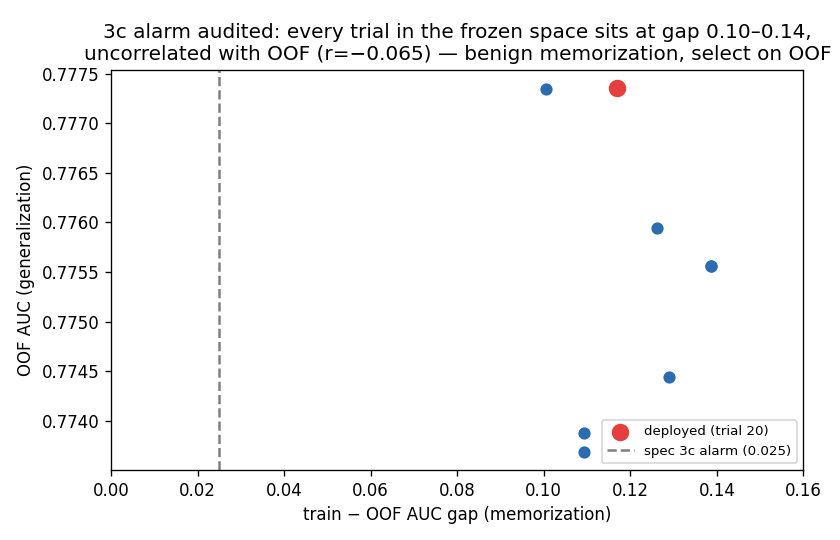

In [6]:
from IPython.display import Image
Image(os.path.join(FIGURES_DIR, "33_gap_vs_oof.png"))

## The honest comparison — what the GBM buys

LightGBM − scorecard = +0.0326 AUC (3.3 points; spec expectation: 2–4 points)


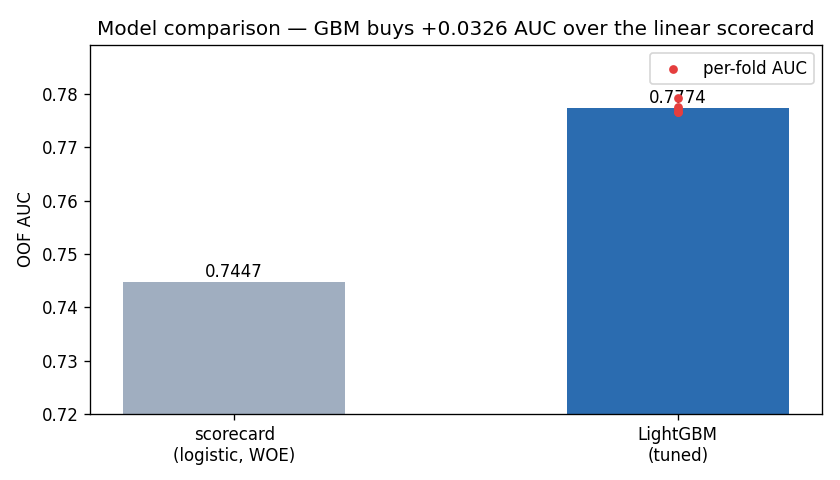

In [7]:
from IPython.display import Image
gap = gbm["oof_auc_pooled"] - sc["oof_auc"]
print(f"LightGBM − scorecard = +{gap:.4f} AUC ({gap*100:.1f} points; spec expectation: 2–4 points)")
Image(os.path.join(FIGURES_DIR, "31_model_comparison.png"))

**Reading the gap like a senior:** the scorecard's ~0.745 is not a failure — it is what a fully auditable, regulator-friendly linear model extracts from this data, and it was *cheap* (25 fits, seconds each). The GBM's extra points come from interactions and non-linearities WOE bins can't express across features. Whether those points are worth the explainability tax is a *business* decision — which is exactly why Phase 5 adds monotonic constraints to the GBM and prices that trade explicitly (expected cost ≤ 0.003 AUC).

**What flows to Phase 4:** `oof_lgbm.parquet` and `oof_scorecard.parquet` — (ID, fold, y, p_raw) per model. Isotonic calibration fits on these OOF predictions; the deployed scorer is the *mean of the 5 fold models*, and the OOF-vs-ensemble distribution overlay (spec 4b) will quantify how closely the calibrator's training distribution matches what it sees in deployment.

**Deferred by design:** SHAP/importance analysis → Phase 5 (on the *constrained* final ensemble, so explanations describe the shipped model, not a predecessor).